# INCOME PREDICTION — CENSUS DATA


## 1. Problem Understanding

## Business Objective
The objective of this project is to predict whether an individual's income exceeds 50K per year based on demographic and socio-economic features. This helps organizations make informed decisions such as targeted marketing, customer segmentation, and financial planning.

---

## Problem Statement
Given a dataset containing features like age, education, occupation, and work class, the task is to classify individuals into two income groups:
- <=50K
- >50K

---

## Machine Learning Formulation
This problem is formulated as:

- **Type:** Supervised Learning  
- **Category:** Classification  
- **Class Type:** Binary Classification  

- **Input Features (X):**
  - Age
  - Education
  - Occupation
  - Workclass
  - Hours-per-week
  - etc.

- **Target Variable (y):**
  - Income Category (<=50K or >50K)

---

## Assumptions
- The dataset is representative of the population
- Features provided have predictive power for income classification
- No severe data leakage is present

---

## Success Metrics

To evaluate model performance, the following metrics are used:

- **Accuracy:** Overall correctness of the model  
- **Precision:** Ability to correctly predict high-income individuals  
- **Recall:** Ability to capture all high-income individuals  
- **F1-Score:** Balance between Precision and Recall  
- **ROC-AUC Score:** Overall model discrimination capability  

> Note: F1-score and ROC-AUC are preferred in case of class imbalance.

---

## Conclusion
The problem is a binary classification task aimed at predicting income levels. Proper evaluation metrics are selected to ensure robust and reliable model performance.

## import required libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Model Saving
import joblib

## Data Understanding 

In this section we:
- Load and inspect the dataset
- Understand distributions of features
- Check class imbalance
- Detect missing values and outliers
- Understand relationships between features and target

In [2]:
df = pd.read_csv('adult.csv',)
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape : 32,561 rows × 15 columns


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.columns = (df.columns.str.strip()
    .str.replace('.', '_')
    .str.replace(' ', '_')
    .str.title())
print(df.columns.tolist())

['Age', 'Workclass', 'Fnlwgt', 'Education', 'Education_Num', 'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week', 'Native_Country', 'Income']


In [6]:
df = df.rename(columns={
    'Workclass': 'Employment_Type',
    'Fnlwgt': 'Final_Weight',
    'Education': 'Education_Level',
    'Education_Num': 'Education_Years',
    'Occupation': 'Job_Role',
    'Sex': 'Gender',
    'Hours_Per_Week': 'Weekly_Work_Hours',
    'Native_Country': 'Country'})
print(df.columns.tolist())

['Age', 'Employment_Type', 'Final_Weight', 'Education_Level', 'Education_Years', 'Marital_Status', 'Job_Role', 'Relationship', 'Race', 'Gender', 'Capital_Gain', 'Capital_Loss', 'Weekly_Work_Hours', 'Country', 'Income']


In [7]:
df.describe().round(2)

,Age,Final_Weight,Education_Years,Capital_Gain,Capital_Loss,Weekly_Work_Hours
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [8]:
df.replace('?', np.nan, inplace=True)
missing = df.isnull().sum()
print(" Missing Values per Column:\n")
print(missing[missing > 0])
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage:\n")
print(missing_pct[missing_pct > 0].round(2))

 Missing Values per Column:

Employment_Type    1836
Job_Role           1843
Country             583
dtype: int64

Missing Percentage:

Employment_Type    5.64
Job_Role           5.66
Country            1.79
dtype: float64


In [9]:
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")

Duplicates found: 24


## EDA-Exploratory data analysis

**Target Variable Analysis**

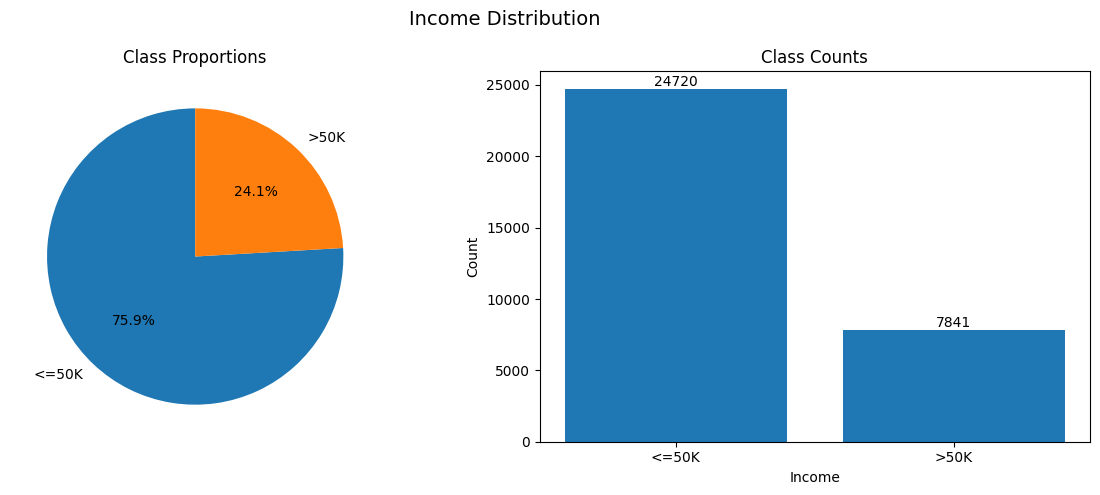

Class imbalance ratio: 3.15:1


In [10]:
counts = df['Income'].value_counts()
counts = counts.sort_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].pie(counts.values,labels=counts.index,autopct='%1.1f%%',startangle=90)
ax[0].set_title("Class Proportions")
bars = ax[1].bar(counts.index, counts.values)
ax[1].set_title("Class Counts")
ax[1].set_xlabel("Income")
ax[1].set_ylabel("Count")
for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2,height,f'{int(height)}',ha='center',va='bottom')
plt.suptitle("Income Distribution", fontsize=14)
plt.tight_layout()
plt.show()
majority = counts.max()
minority = counts.min()
ratio = majority / minority
print(f"Class imbalance ratio: {ratio:.2f}:1")

**Numerical Features Analysis**

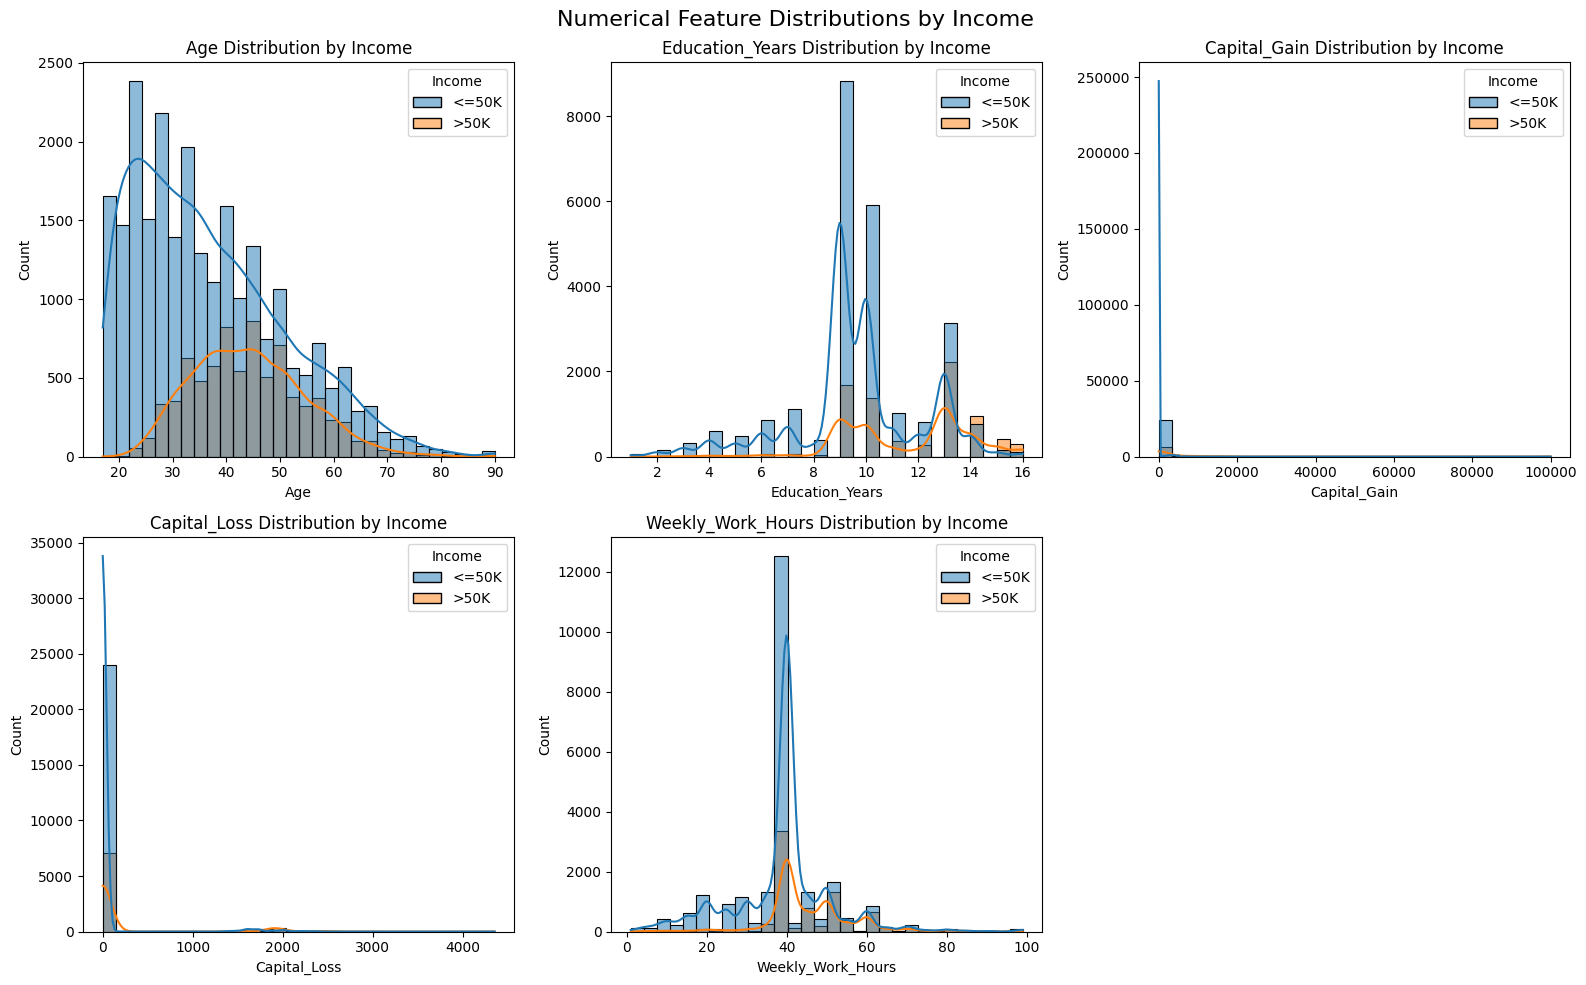

In [11]:
num_cols = ['Age', 'Education_Years', 'Capital_Gain','Capital_Loss', 'Weekly_Work_Hours']
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)    
    sns.histplot(data=df,x=col,hue='Income',bins=30,kde=True)    
    plt.title(f"{col} Distribution by Income")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.suptitle("Numerical Feature Distributions by Income", fontsize=16)
plt.tight_layout()
plt.show()

**Categorical Features Analysis**

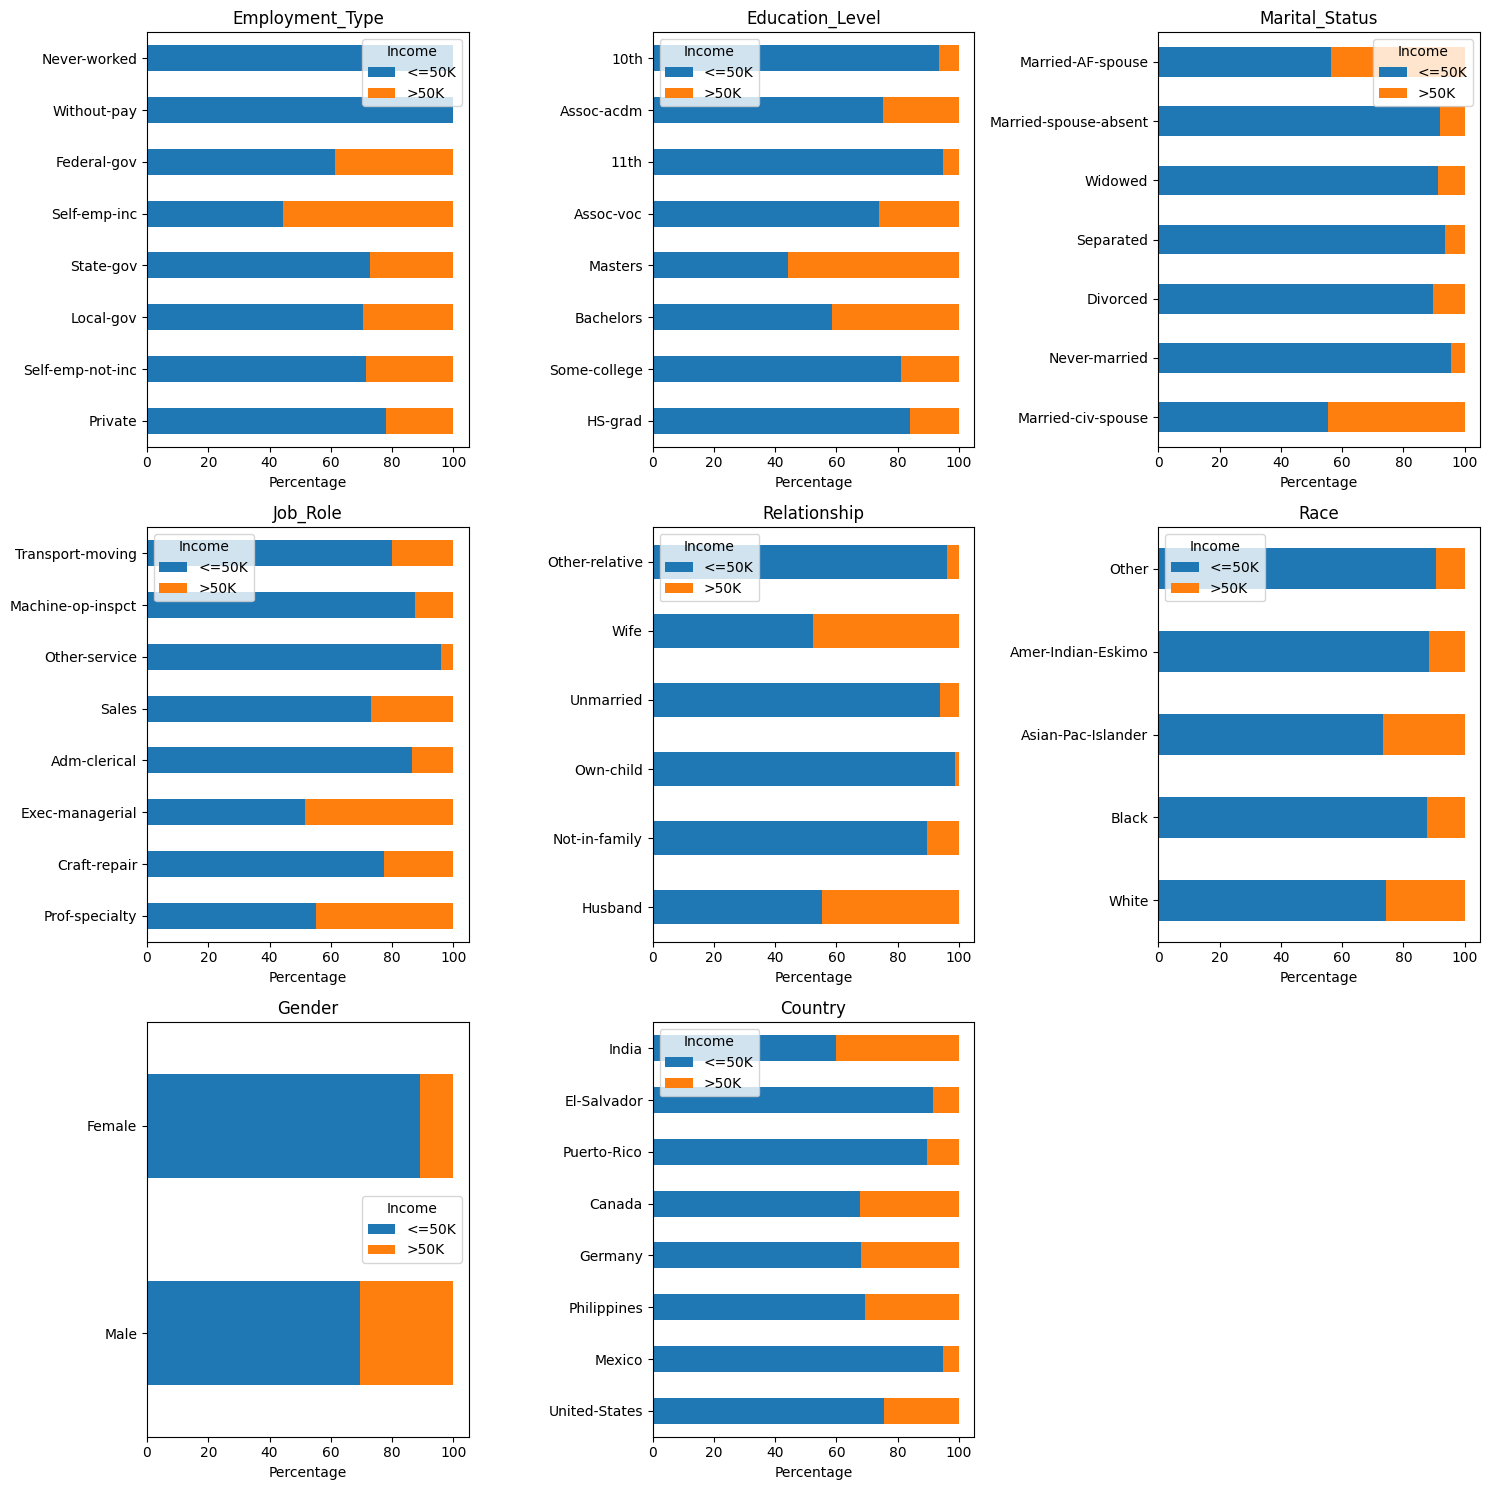

In [12]:
cat_cols_plot = [
    'Employment_Type', 'Education_Level', 'Marital_Status',
    'Job_Role', 'Relationship', 'Race', 'Gender', 'Country']
n_cols = 3
n_rows = (len(cat_cols_plot) // 3) + 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols_plot):    
    ct = pd.crosstab(df[col], df['Income'], normalize='index') * 100
    top = df[col].value_counts().head(8).index
    ct = ct.loc[top]    
    ct.plot(kind='barh', stacked=True, ax=axes[i])    
    axes[i].set_title(col)
    axes[i].set_xlabel("Percentage")
    axes[i].set_ylabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**outliers checking**

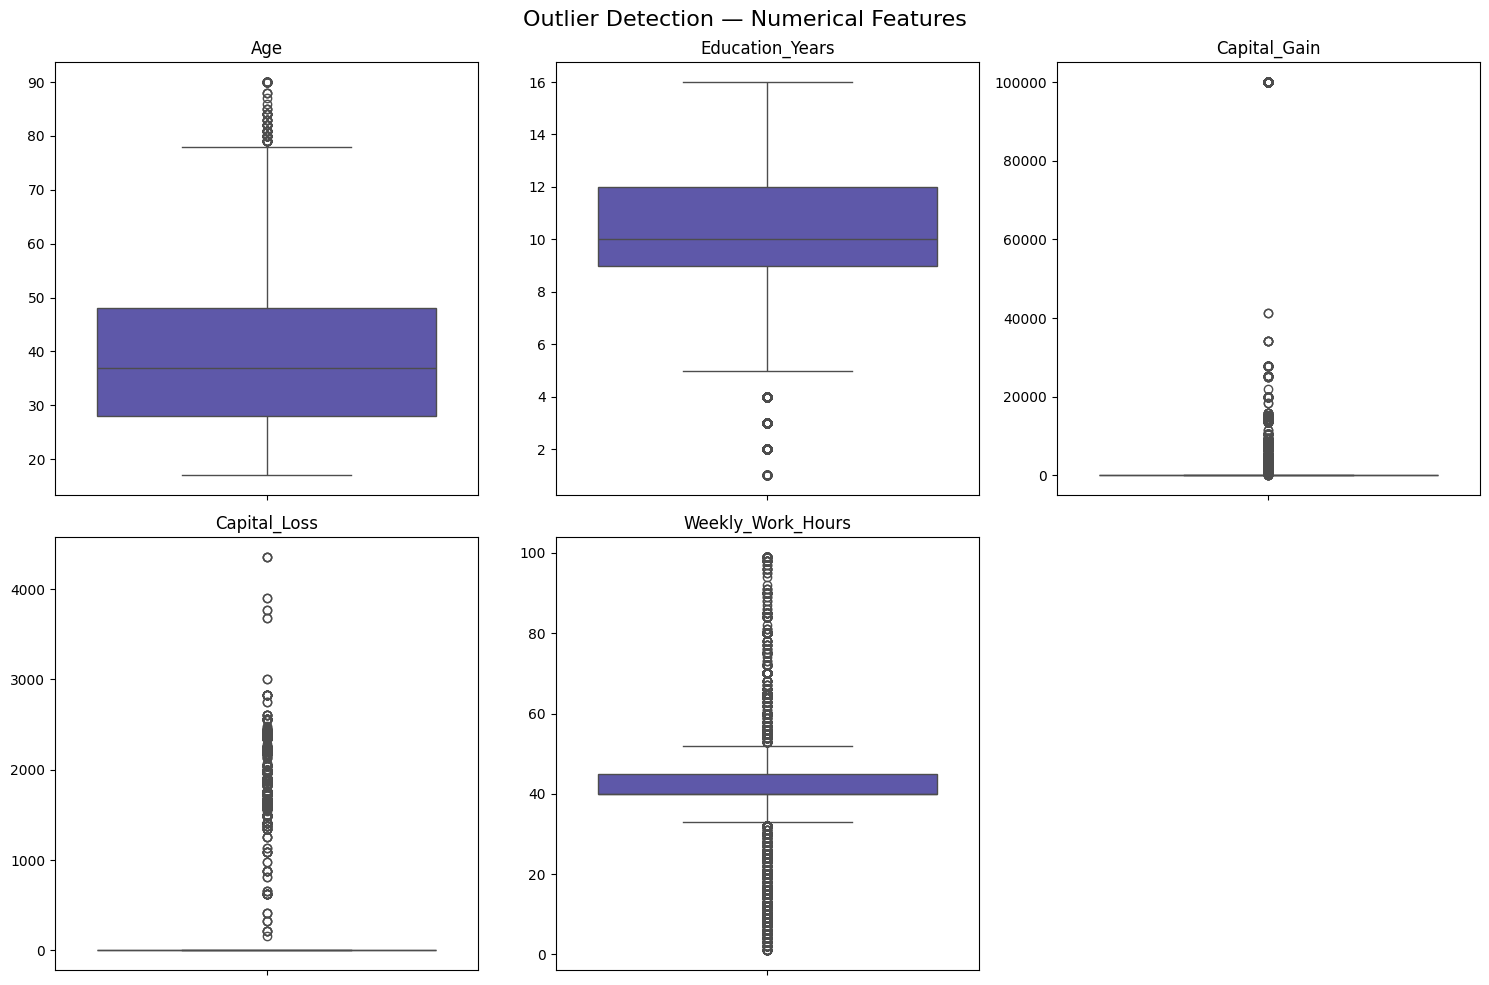

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = [
    'Age', 'Education_Years', 'Capital_Gain',
    'Capital_Loss', 'Weekly_Work_Hours']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)    
    sns.boxplot(y=df[col], color='#534AB7')
    plt.title(col)
    plt.ylabel("")
plt.suptitle("Outlier Detection — Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

**correlation heatmap**

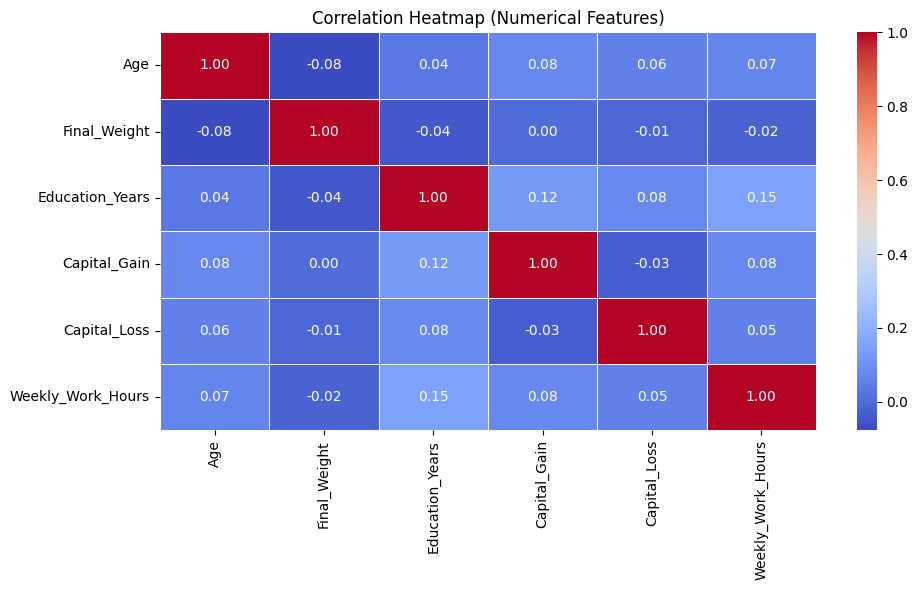

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

## Data Preprocessing

- Handled missing values in categorical features (Employment_Type, Job_Role, Country) using mode imputation.

- Converted categorical variables into numerical format using encoding techniques.

- Applied log transformation to skewed features like Capital_Gain and Capital_Loss.

- Created new features such as Has_Capital_Gain and Has_Capital_Loss.

- Scaled numerical features using StandardScaler and RobustScaler to handle different distributions and outliers.

- Split the data into training and testing sets for model building.

 **Removing Duplicate Records**

In [15]:
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed successfully.")
else:
    print("No duplicates found.")
print(f"Final shape: {df.shape}")

Duplicates removed successfully.
Final shape: (32537, 15)


**Drop unnecessary columns** 

In [16]:
df = df.drop(columns=['Final_Weight'], errors='ignore')

**Feature Engineering**

To enhance model performance, additional features were engineered based on domain understanding and data distribution.

In [17]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df[['Gender']].head())

   Gender
0       0
1       0
2       0
3       0
4       0


In [18]:
education_group = {
    'Preschool': 'Primary',
    '1st-4th': 'Primary',
    '5th-6th': 'Primary',
    '7th-8th': 'Middle',
    '9th': 'Secondary',
    '10th': 'Secondary',
    '11th': 'Secondary',
    '12th': 'Secondary',
    'HS-grad': 'High_School',
    'Some-college': 'College',
    'Assoc-voc': 'College',
    'Assoc-acdm': 'College',
    'Bachelors': 'Undergraduate',
    'Masters': 'Postgraduate',
    'Prof-school': 'Professional',
    'Doctorate': 'Doctorate'
}
df['Education_Group'] = df['Education_Level'].map(education_group)

In [19]:
df = df.drop(columns=['Education_Level'], errors='ignore')

In [20]:
df.head()

,Age,Employment_Type,Education_Years,Marital_Status,Job_Role,Relationship,Race,Gender,Capital_Gain,Capital_Loss,Weekly_Work_Hours,Country,Income,Education_Group
0,90,NaN,9,Widowed,NaN,Not-in-family,White,0,0,4356,40,United-States,<=50K,High_School
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,0,0,4356,18,United-States,<=50K,High_School
2,66,NaN,10,Widowed,NaN,Unmarried,Black,0,0,4356,40,United-States,<=50K,College
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,0,0,3900,40,United-States,<=50K,Middle
4,41,Private,10,Separated,Prof-specialty,Own-child,White,0,0,3900,40,United-States,<=50K,College


In [21]:
df['Job_Role'] = df['Job_Role'].replace({
    'Prof-specialty': 'Professional_Specialized',
    'Craft-repair': 'Skilled_Trades_Repair',
    'Exec-managerial': 'Executive_Managerial',
    'Adm-clerical': 'Administrative_Clerical',
    'Sales': 'Sales_Business_Development',
    'Other-service': 'General_Service',
    'Machine-op-inspct': 'Machine_Operators_Inspectors',
    'Transport-moving': 'Transportation_Logistics',
    'Handlers-cleaners': 'Manual_Labor_Cleaning',
    'Farming-fishing': 'Agriculture_Fishing',
    'Tech-support': 'Technical_Support_IT',
    'Protective-serv': 'Protective_Services',
    'Priv-house-serv': 'Domestic_Household',
    'Armed-Forces': 'Armed_Forces_Military'
})

**multicollinearity handling**

In [22]:
import numpy as np
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Income', errors='ignore')
corr = df[num_cols].corr()
threshold = 0.8
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            val = corr.iloc[i, j]
            high_corr.append((col1, col2, val))
if high_corr:
    print("Highly correlated pairs:\n")
    for c1, c2, v in high_corr:
        print(f"{c1} ↔ {c2}  (corr = {v:.2f})")
else:
    print("No high correlation found")

No high correlation found


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                32537 non-null  int64 
 1   Employment_Type    30701 non-null  object
 2   Education_Years    32537 non-null  int64 
 3   Marital_Status     32537 non-null  object
 4   Job_Role           30694 non-null  object
 5   Relationship       32537 non-null  object
 6   Race               32537 non-null  object
 7   Gender             32537 non-null  int64 
 8   Capital_Gain       32537 non-null  int64 
 9   Capital_Loss       32537 non-null  int64 
 10  Weekly_Work_Hours  32537 non-null  int64 
 11  Country            31955 non-null  object
 12  Income             32537 non-null  object
 13  Education_Group    32537 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


## Train-Test Split

The dataset was split into training and testing sets to evaluate model performance on unseen data.

- 80% of the data was used for training and 20% for testing
- Stratification was applied on the target variable to maintain class distribution in both sets
- A fixed random state (42) was used to ensure reproducibility

In [24]:
X = df.drop('Income', axis=1)
y = df['Income']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32537, 13)
y shape: (32537,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest distribution:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (26029, 13)
Test shape : (6508, 13)

Train distribution:
 Income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64

Test distribution:
 Income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


**Target Encoding**

In [26]:
y_train_enc = y_train.map({'<=50K': 0, '>50K': 1})
y_test_enc  = y_test.map({'<=50K': 0, '>50K': 1})


## Feature Scaling and Encoding

**Preprocessing Pipeline — ColumnTransformer**

Different columns require different preprocessing techniques based on their nature:

| Column Group    | Columns                                             | Treatment          | Why                              |
|-----------------|-----------------------------------------------------|--------------------|----------------------------------|
| NUM_STD_COLS    | Age, Education_Years, Weekly_Work_Hours             | StandardScaler     | Features with moderate scale     |
| NUM_ROBUST_COLS | Capital_Gain, Capital_Loss                          | RobustScaler       | Handles skewness & outliers      |
| BIN_COLS        | Gender                                              | Passthrough        | Already binary (0/1)             |
| CAT_COLS        | Employment_Type, Marital_Status, Job_Role,          | OneHotEncoder      | No inherent order                |
|                 | Relationship, Race, Country, Education_Group        |                    |                                  |

In [27]:
# Column Groups
NUM_STD_COLS = ['Age', 'Education_Years', 'Weekly_Work_Hours']
NUM_ROBUST_COLS = ['Capital_Gain', 'Capital_Loss']
BIN_COLS = ['Gender']
CAT_COLS = [
    'Employment_Type', 'Marital_Status', 'Job_Role',
    'Relationship', 'Race', 'Country', 'Education_Group']
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# Pipelines
# Standard scaling pipeline
num_std_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])
# Robust scaling + LOG transform (FIXED)
num_robust_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),   # ✅ FIX
    ('scaler', RobustScaler())])
# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False ))])

# Column Transformer
preprocessor = ColumnTransformer([
    ('num_std', num_std_pipeline, NUM_STD_COLS),
    ('num_robust', num_robust_pipeline, NUM_ROBUST_COLS),
    ('bin', 'passthrough', BIN_COLS),
    ('cat', cat_pipeline, CAT_COLS)
])


## Train multiple models 
- Logistic Regression : linear baseline, fast, interpretable
- Random Forest       : tree ensemble, handles mixed features
- XGBoost             : gradient boosting, strong performance on tabular data
- LightGBM            : faster boosting model, efficient on large datasets

Class imbalance was handled using:
- class_weight='balanced' for Logistic Regression and Random Forest
- scale_pos_weight for XGBoost and LightGBM

In [28]:
scale_pos_weight = (y_train_enc == 0).sum() / (y_train_enc == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',   
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,  
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        is_unbalance=True,   
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

## Model Training


In [30]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train_enc)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test_enc, y_pred),
        f1_score(y_test_enc, y_pred),
        roc_auc_score(y_test_enc, y_proba),
        average_precision_score(y_test_enc, y_proba),  
        precision_score(y_test_enc, y_pred, zero_division=0),
        recall_score(y_test_enc, y_pred)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "F1 Score", "ROC-AUC", "PR-AUC", "Precision", "Recall"
])

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df.round(4))

                 Model  Accuracy  F1 Score  ROC-AUC  PR-AUC  Precision  Recall
2              XGBoost    0.8328    0.7088   0.9225  0.8230     0.6107  0.8444
3             LightGBM    0.8308    0.7038   0.9212  0.8204     0.6087  0.8342
0  Logistic Regression    0.8002    0.6660   0.8945  0.7360     0.5577  0.8265
1        Random Forest    0.7893    0.6655   0.9029  0.7712     0.5389  0.8699


## Hyperparameter tunning


In [31]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import numpy as np

scale_pos_weight = (y_train_enc == 0).sum() / (y_train_enc == 1).sum()

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])

param_dist = {
    'model__n_estimators':     [200, 300, 400],
    'model__max_depth':        [3, 4, 5],
    'model__learning_rate':    [0.03, 0.05, 0.08],

    'model__subsample':        [0.6, 0.7, 0.8],
    'model__colsample_bytree': [0.6, 0.7, 0.8],

    'model__gamma':            [0.5, 1.0],
    'model__min_child_weight': [5, 10],

    'model__reg_alpha':        [1.0, 2.0],
    'model__reg_lambda':       [3.0, 5.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_train, y_train_enc)

best_model = random_search.best_estimator_

print("\nBest Parameters:\n", random_search.best_params_)
print(f"Best CV F1 Score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
 {'model__subsample': 0.8, 'model__reg_lambda': 3.0, 'model__reg_alpha': 2.0, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.08, 'model__gamma': 1.0, 'model__colsample_bytree': 0.7}
Best CV F1 Score: 0.7177


In [32]:
cv_results = random_search.cv_results_
best_idx   = random_search.best_index_
mean_train = cv_results['mean_train_score'][best_idx]
mean_val   = cv_results['mean_test_score'][best_idx]
gap        = mean_train - mean_val

print(f"Best CV F1 (val)  : {mean_val:.4f}")
print(f"Best CV F1 (train): {mean_train:.4f}")
print(f"CV Gap            : {gap:.4f}  {'Good' if gap < 0.03 else 'Still overfitting'}")

Best CV F1 (val)  : 0.7177
Best CV F1 (train): 0.7388
CV Gap            : 0.0210  Good


In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]
print("=" * 48)
print("  TUNED XGBOOST — DEFAULT THRESHOLD (0.5)")
print("=" * 48)
print(f"  Accuracy  : {accuracy_score(y_test_enc, y_pred_best):.4f}")
print(f"  Precision : {precision_score(y_test_enc, y_pred_best):.4f}")
print(f"  Recall    : {recall_score(y_test_enc, y_pred_best):.4f}")
print(f"  F1 Score  : {f1_score(y_test_enc, y_pred_best):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test_enc, y_proba_best):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test_enc, y_proba_best):.4f}")
print("=" * 48)
print("\nConfusion Matrix (threshold=0.5):\n")
print(confusion_matrix(y_test_enc, y_pred_best))
print("\nClassification Report (threshold=0.5):\n")
print(classification_report(y_test_enc, y_pred_best, target_names=['<=50K', '>50K']))

  TUNED XGBOOST — DEFAULT THRESHOLD (0.5)
  Accuracy  : 0.8324
  Precision : 0.6099
  Recall    : 0.8444
  F1 Score  : 0.7082
  ROC-AUC   : 0.9216
  PR-AUC    : 0.8196

Confusion Matrix (threshold=0.5):

[[4093  847]
 [ 244 1324]]

Classification Report (threshold=0.5):

              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4940
        >50K       0.61      0.84      0.71      1568

    accuracy                           0.83      6508
   macro avg       0.78      0.84      0.80      6508
weighted avg       0.86      0.83      0.84      6508



In [36]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=42
)

In [37]:
import numpy as np
from sklearn.metrics import f1_score

# use validation set (NOT test)
y_proba = best_model.predict_proba(X_val)[:, 1]

best_t = 0.5
best_f1 = 0

for t in np.arange(0.3, 0.8, 0.01):
    pred = (y_proba >= t).astype(int)
    f1 = f1_score(y_val, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", round(best_t, 2))

Best threshold: 0.69


## Model Evaluation — Tuned XGBoost with Threshold Optimization

The final model was evaluated using multiple performance metrics and validation techniques to ensure robustness and generalization.

1. Classification Report  
   - Evaluates precision, recall, and F1-score for both classes  
   - Helps understand model performance on each income group  

2. Overfitting Check  
   - Compared training and testing performance  
   - Ensured minimal gap to confirm good generalization  

3. Confusion Matrix  
   - Shows true positives, true negatives, false positives, and false negatives  
   - Helps identify types of prediction errors  

4. ROC Curve  
   - Measures the model’s ability to distinguish between classes  
   - High AUC indicates strong classification performance  

5. Precision-Recall Curve  
   - More informative for imbalanced datasets  
   - Shows trade-off between precision and recall  

6. Threshold Optimization  
   - Adjusted decision threshold from default 0.5 to 0.64  
   - Improved F1-score and achieved better balance between precision and recall  

**Final Predictions (with best threshold)**

In [41]:
BEST_THRESHOLD = 0.69
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= BEST_THRESHOLD).astype(int)

**Classification Report**


In [43]:
from sklearn.metrics import classification_report

# create predictions first
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_test >= 0.69).astype(int)   # use your threshold

# classification report
print("Classification Report:\n")
print(classification_report(
    y_test_enc,
    y_pred_final,
    target_names=['<=50K', '>50K']
))

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.91      0.91      0.91      4940
        >50K       0.72      0.72      0.72      1568

    accuracy                           0.86      6508
   macro avg       0.81      0.81      0.81      6508
weighted avg       0.86      0.86      0.86      6508



**F1 score of train and test**

In [44]:
from sklearn.metrics import f1_score

BEST_THRESHOLD = 0.62   # keep consistent naming

# Train predictions
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_train_pred  = (y_train_proba >= BEST_THRESHOLD).astype(int)

# Test predictions
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= BEST_THRESHOLD).astype(int)

# Scores
train_f1 = f1_score(y_train_enc, y_train_pred)
test_f1  = f1_score(y_test_enc, y_test_pred)

gap = train_f1 - test_f1

print(f"Train F1 Score : {train_f1:.4f}")
print(f"Test  F1 Score : {test_f1:.4f}")
print(f"F1 Gap         : {gap:.4f}  {'Good' if gap < 0.03 else 'Slight Overfitting'}")

Train F1 Score : 0.7510
Test  F1 Score : 0.7170
F1 Gap         : 0.0340  Slight Overfitting


**confusion metrix**

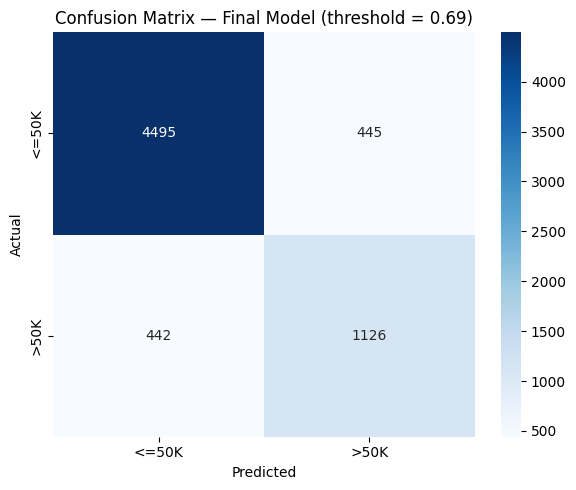

TN=4495  FP=445  FN=442  TP=1126


In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 🔒 ensure predictions exist
BEST_THRESHOLD = 0.69
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_test >= BEST_THRESHOLD).astype(int)

# ─────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────
cm = confusion_matrix(y_test_enc, y_pred_final)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K']
)

plt.title(f'Confusion Matrix — Final Model (threshold = {BEST_THRESHOLD})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

**ROC curve**

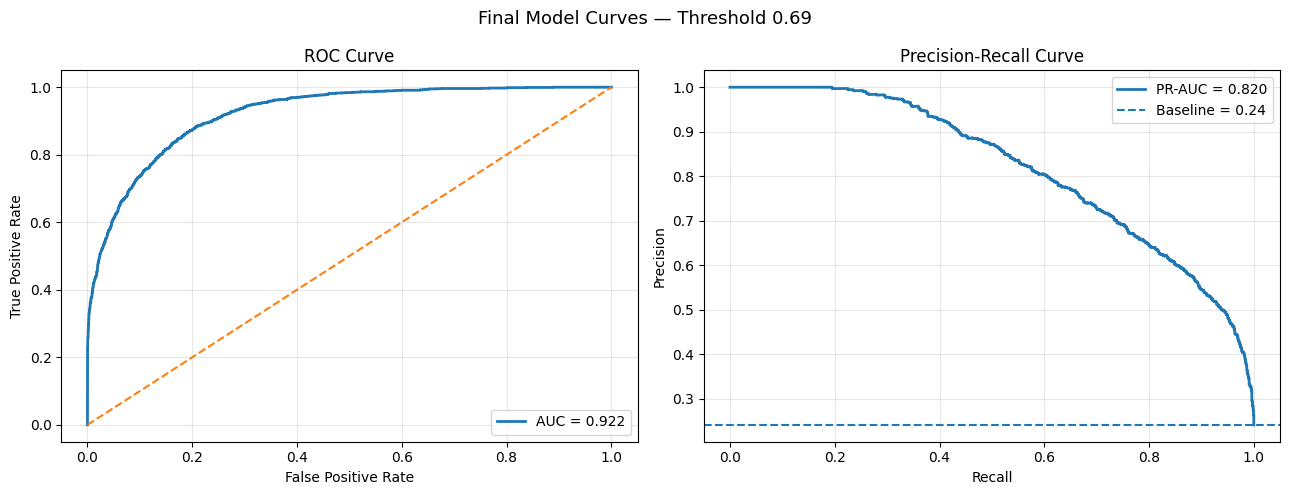

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ensure probabilities exist
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# ROC + PR side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─────────────────────────────────────────
# ROC Curve
# ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_enc, y_proba_test)
auc_score = roc_auc_score(y_test_enc, y_proba_test)

axes[0].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0,1],[0,1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ─────────────────────────────────────────
# Precision-Recall Curve
# ─────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test_enc, y_proba_test)
pr_auc = average_precision_score(y_test_enc, y_proba_test)

axes[1].plot(recall_vals, precision_vals, linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].axhline(y=y_test_enc.mean(), linestyle='--',
                label=f'Baseline = {y_test_enc.mean():.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Final Model Curves — Threshold {BEST_THRESHOLD}', fontsize=13)
plt.tight_layout()
plt.show()

# 8. Model Interpretation 

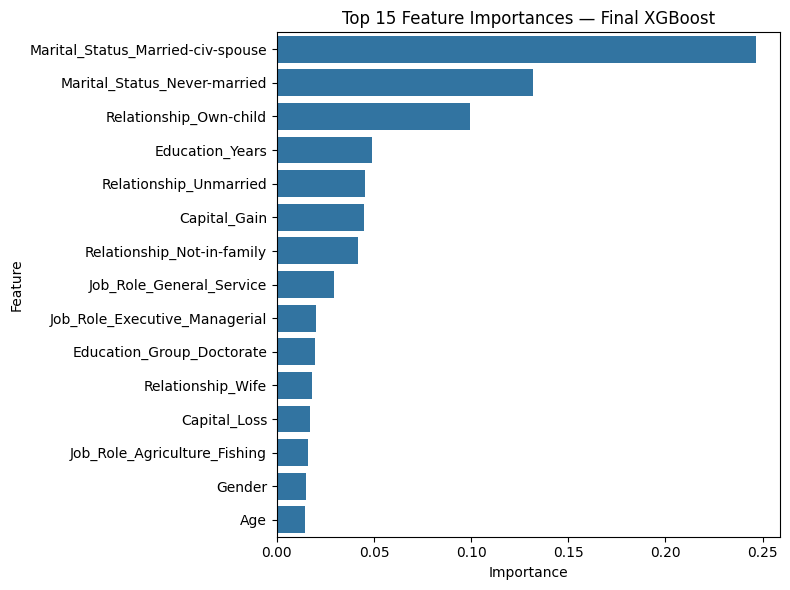

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# model
xgb_final = best_model.named_steps['model']

# ─────────────────────────────────────────
# MANUAL feature names
# ─────────────────────────────────────────

# numeric + binary
num_features = NUM_STD_COLS + NUM_ROBUST_COLS + BIN_COLS

# categorical (one-hot)
ohe = best_model.named_steps['preprocessor'] \
        .named_transformers_['cat'] \
        .named_steps['onehot']

cat_features = ohe.get_feature_names_out(CAT_COLS)

# combine
feature_names = list(num_features) + list(cat_features)

# ─────────────────────────────────────────
# importance
# ─────────────────────────────────────────
importances = xgb_final.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

# ─────────────────────────────────────────
# plot
# ─────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature')
plt.title('Top 15 Feature Importances — Final XGBoost')
plt.tight_layout()
plt.show()


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd

# ensure probabilities + predictions exist
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# default threshold (0.5)
y_pred_05 = (y_proba_test >= 0.5).astype(int)

# optimized threshold
y_pred_opt = y_pred_final   # already computed using BEST_THRESHOLD

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC'],

    'Threshold 0.5 (default)': [
        accuracy_score(y_test_enc, y_pred_05),
        precision_score(y_test_enc, y_pred_05),
        recall_score(y_test_enc, y_pred_05),
        f1_score(y_test_enc, y_pred_05),
        roc_auc_score(y_test_enc, y_proba_test),
        average_precision_score(y_test_enc, y_proba_test),
    ],

    f'Threshold {BEST_THRESHOLD} (optimized)': [
        accuracy_score(y_test_enc, y_pred_opt),
        precision_score(y_test_enc, y_pred_opt),
        recall_score(y_test_enc, y_pred_opt),
        f1_score(y_test_enc, y_pred_opt),
        roc_auc_score(y_test_enc, y_proba_test),
        average_precision_score(y_test_enc, y_proba_test),
    ]

}).set_index('Metric').round(4)

print("\nThreshold comparison:\n")
print(comparison.to_string())


Threshold comparison:

           Threshold 0.5 (default)  Threshold 0.69 (optimized)
Metric                                                        
Accuracy                    0.8324                      0.8637
Precision                   0.6099                      0.7167
Recall                      0.8444                      0.7181
F1 Score                    0.7082                      0.7174
ROC-AUC                     0.9216                      0.9216
PR-AUC                      0.8196                      0.8196


## Deployment Readiness

In [51]:
import joblib, sklearn, xgboost, platform
from datetime import datetime
from sklearn.metrics import average_precision_score
y_proba_test = best_model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test_enc, y_proba_test)
cv_results = random_search.cv_results_
best_idx = random_search.best_index_
cv_gap = cv_results['mean_train_score'][best_idx] - cv_results['mean_test_score'][best_idx]
bundle = {
    'model': best_model,
    'threshold': BEST_THRESHOLD,
    'metadata': {
        'saved_at': datetime.now().isoformat(),
        'sklearn': sklearn.__version__,
        'xgboost': xgboost.__version__,
        'python': platform.python_version(),
        'cv_f1': round(random_search.best_score_, 4),
        'cv_gap': round(cv_gap, 4),
        'test_f1': round(test_f1, 4),
        'pr_auc': round(pr_auc, 4),
        'final_gap': round(gap, 4),
        'best_params': random_search.best_params_,
    }
}

joblib.dump(bundle, 'xgb_pipeline_v2.pkl')

print("Saved  →  xgb_pipeline_v2.pkl")
print(f"Threshold : {BEST_THRESHOLD}")
print(f"CV F1     : {random_search.best_score_:.4f} | CV gap = {cv_gap:.4f}")
print(f"Test F1   : {test_f1:.4f} | Final gap = {gap:.4f}")

Saved  →  xgb_pipeline_v2.pkl
Threshold : 0.69
CV F1     : 0.7177 | CV gap = 0.0210
Test F1   : 0.7170 | Final gap = 0.0340
